In [72]:
import pandas as pd
from sklearn.model_selection import train_test_split
import numpy as np
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
import seaborn as sns

In [73]:
df = pd.read_csv("smartcart_customers.csv")
df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response
0,5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,...,172,88,88,3,8,10,4,7,0,1
1,2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,...,2,1,6,2,1,1,2,5,0,0
2,4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,...,111,21,42,1,8,2,10,4,0,0
3,6182,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,11,...,10,3,5,2,2,0,4,6,0,0
4,5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,...,46,27,15,5,5,3,6,5,0,0


In [74]:
df.shape

(2240, 22)

In [75]:
df.isnull().any()

ID                     False
Year_Birth             False
Education              False
Marital_Status         False
Income                  True
Kidhome                False
Teenhome               False
Dt_Customer            False
Recency                False
MntWines               False
MntFruits              False
MntMeatProducts        False
MntFishProducts        False
MntSweetProducts       False
MntGoldProds           False
NumDealsPurchases      False
NumWebPurchases        False
NumCatalogPurchases    False
NumStorePurchases      False
NumWebVisitsMonth      False
Complain               False
Response               False
dtype: bool

# Filling Null Values

In [76]:
df["Income"]  =df["Income"].fillna(df["Income"].median())

# Feature Engineering

In [77]:
# Age 
df["Age"] = 2026-df["Year_Birth"]

#Converting Date to Days
df["Dt_Customer"] = pd.to_datetime(df["Dt_Customer"],dayfirst = True)
reference_date = df["Dt_Customer"].max()
df["Customer_Tenure_Days"] = (reference_date - df["Dt_Customer"]).dt.days

In [78]:
# Total money spent
df.columns

Index(['ID', 'Year_Birth', 'Education', 'Marital_Status', 'Income', 'Kidhome',
       'Teenhome', 'Dt_Customer', 'Recency', 'MntWines', 'MntFruits',
       'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts',
       'MntGoldProds', 'NumDealsPurchases', 'NumWebPurchases',
       'NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth',
       'Complain', 'Response', 'Age', 'Customer_Tenure_Days'],
      dtype='object')

In [79]:
df["Total_Spent"] = df["MntWines"] + df["MntFishProducts"] + df["MntFruits"] + df["MntGoldProds"] + df["MntMeatProducts"] + df["MntSweetProducts"]

df["Total_Children"] = df["Kidhome"] + df["Teenhome"]

In [80]:
# Undergraduate, Graduate, Postgraduate

df["Education"] = df["Education"].replace({
    "Basic":"Undergraduate",
    "2n Cycle":"Undergraduate",
    "Graduation":"Graduate",
    "PhD":"Postgraduate",
    "Master":"Postgraduate"
})

In [81]:
#Marital Status

df["Living_With"] = df["Marital_Status"].replace({
    "Married":"Partner",
    "Together":"Partner",
    "Single":"Alone",
    "YOLO":"Alone",
    "Absurd":"Alone",
    "Widow":"Alone",
    "Alone":"Alone",
    "Divorced":"Alone",
})

In [82]:
df.columns

Index(['ID', 'Year_Birth', 'Education', 'Marital_Status', 'Income', 'Kidhome',
       'Teenhome', 'Dt_Customer', 'Recency', 'MntWines', 'MntFruits',
       'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts',
       'MntGoldProds', 'NumDealsPurchases', 'NumWebPurchases',
       'NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth',
       'Complain', 'Response', 'Age', 'Customer_Tenure_Days', 'Total_Spent',
       'Total_Children', 'Living_With'],
      dtype='object')

In [83]:
cols = ["ID","Year_Birth","Marital_Status","Kidhome","Teenhome","Dt_Customer"]
spending_cols = ["MntWines","MntSweetProducts","MntGoldProds","MntFishProducts","MntMeatProducts","MntFruits"]
df_cleaned = df.drop(columns=cols+spending_cols)

In [84]:
df_cleaned.shape

(2240, 15)

In [85]:
df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,Age,Customer_Tenure_Days,Total_Spent,Total_Children,Living_With
0,5524,1957,Graduate,Single,58138.0,0,0,2012-09-04,58,635,...,10,4,7,0,1,69,663,1617,0,Alone
1,2174,1954,Graduate,Single,46344.0,1,1,2014-03-08,38,11,...,1,2,5,0,0,72,113,27,2,Alone
2,4141,1965,Graduate,Together,71613.0,0,0,2013-08-21,26,426,...,2,10,4,0,0,61,312,776,0,Partner
3,6182,1984,Graduate,Together,26646.0,1,0,2014-02-10,26,11,...,0,4,6,0,0,42,139,53,1,Partner
4,5324,1981,Postgraduate,Married,58293.0,1,0,2014-01-19,94,173,...,3,6,5,0,0,45,161,422,1,Partner


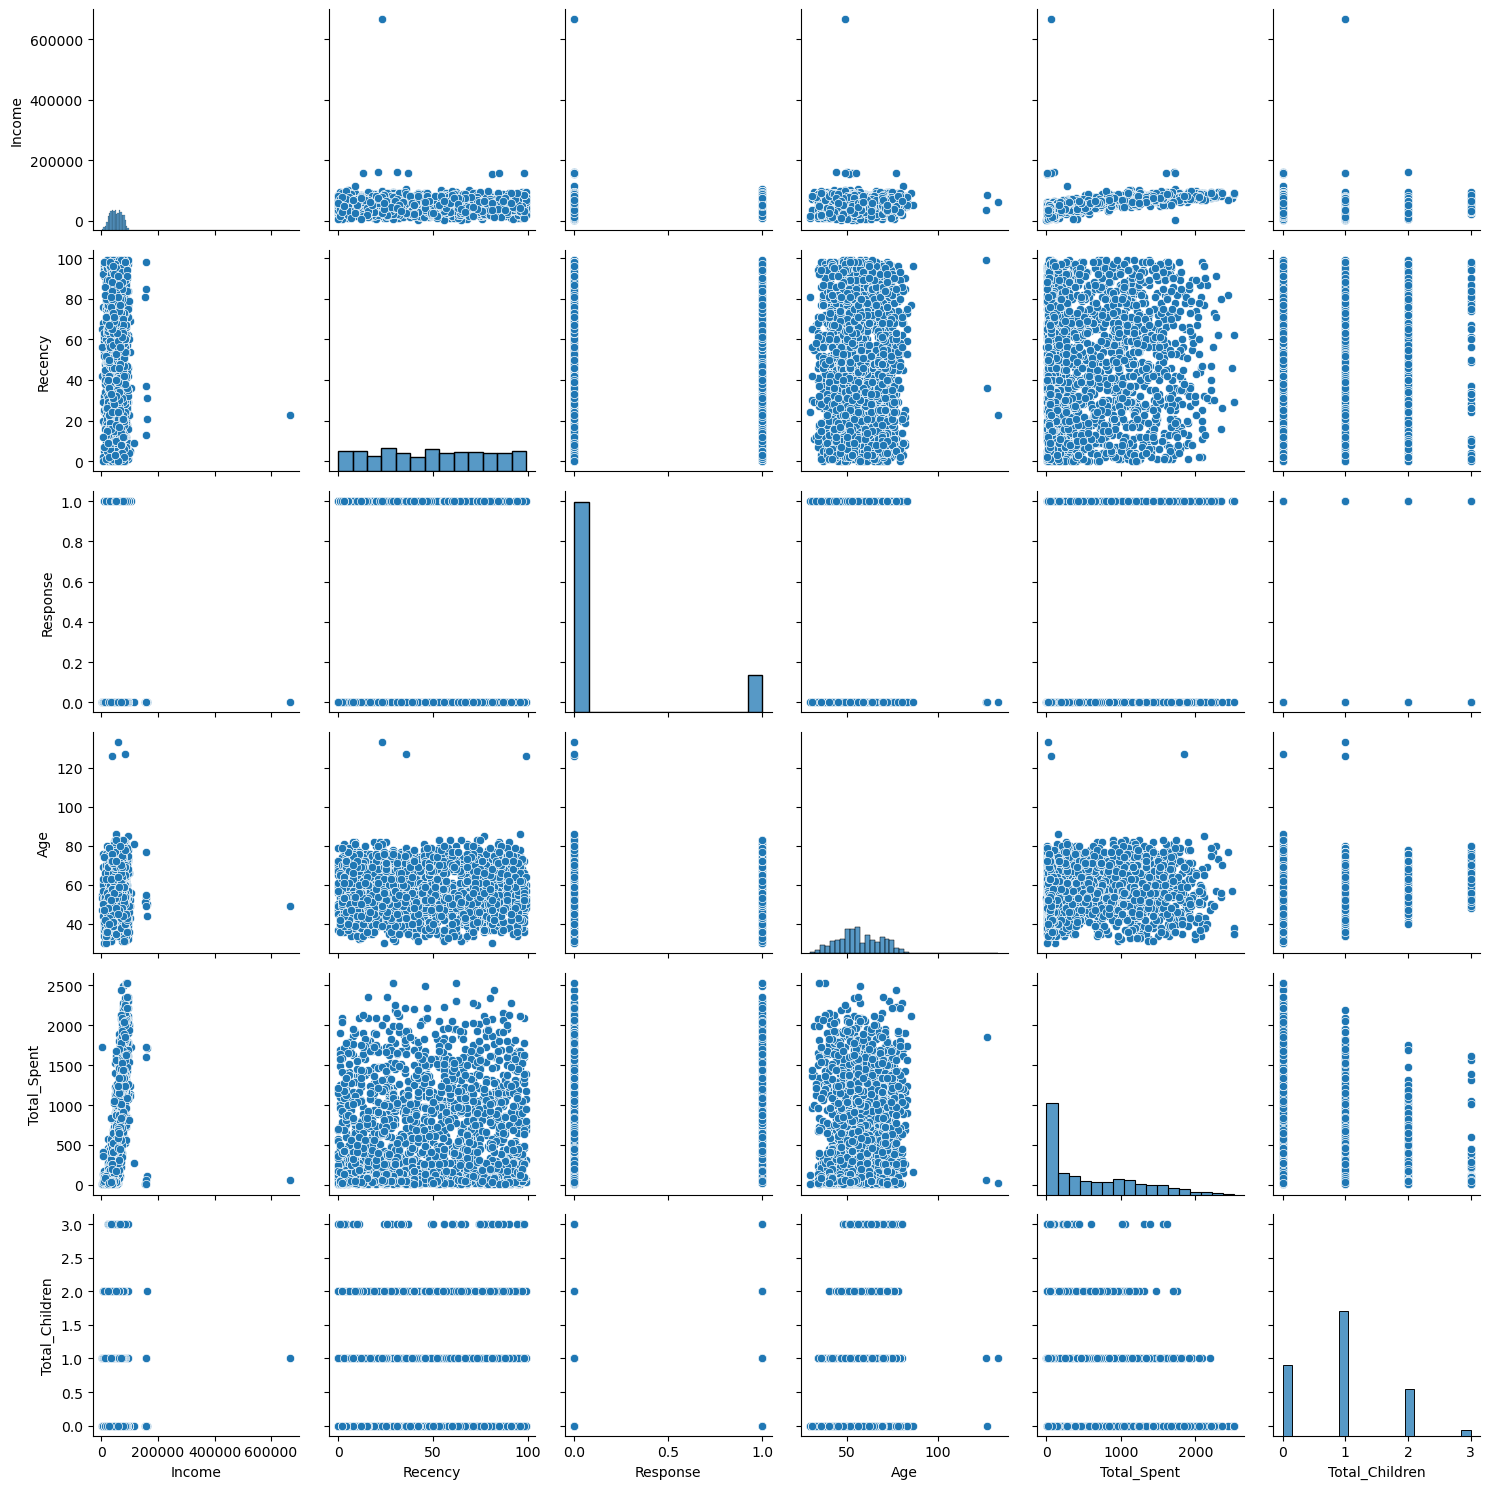

In [86]:
# Outliers

cols = ["Income","Recency","Response","Age","Total_Spent","Total_Children"]

sns.pairplot(df_cleaned[cols])
plt.tight_layout()

In [87]:
df_cleaned = df_cleaned[ (df_cleaned["Age"]<90) ]
df_cleaned = df_cleaned[ (df_cleaned["Income"]< 600000) ]

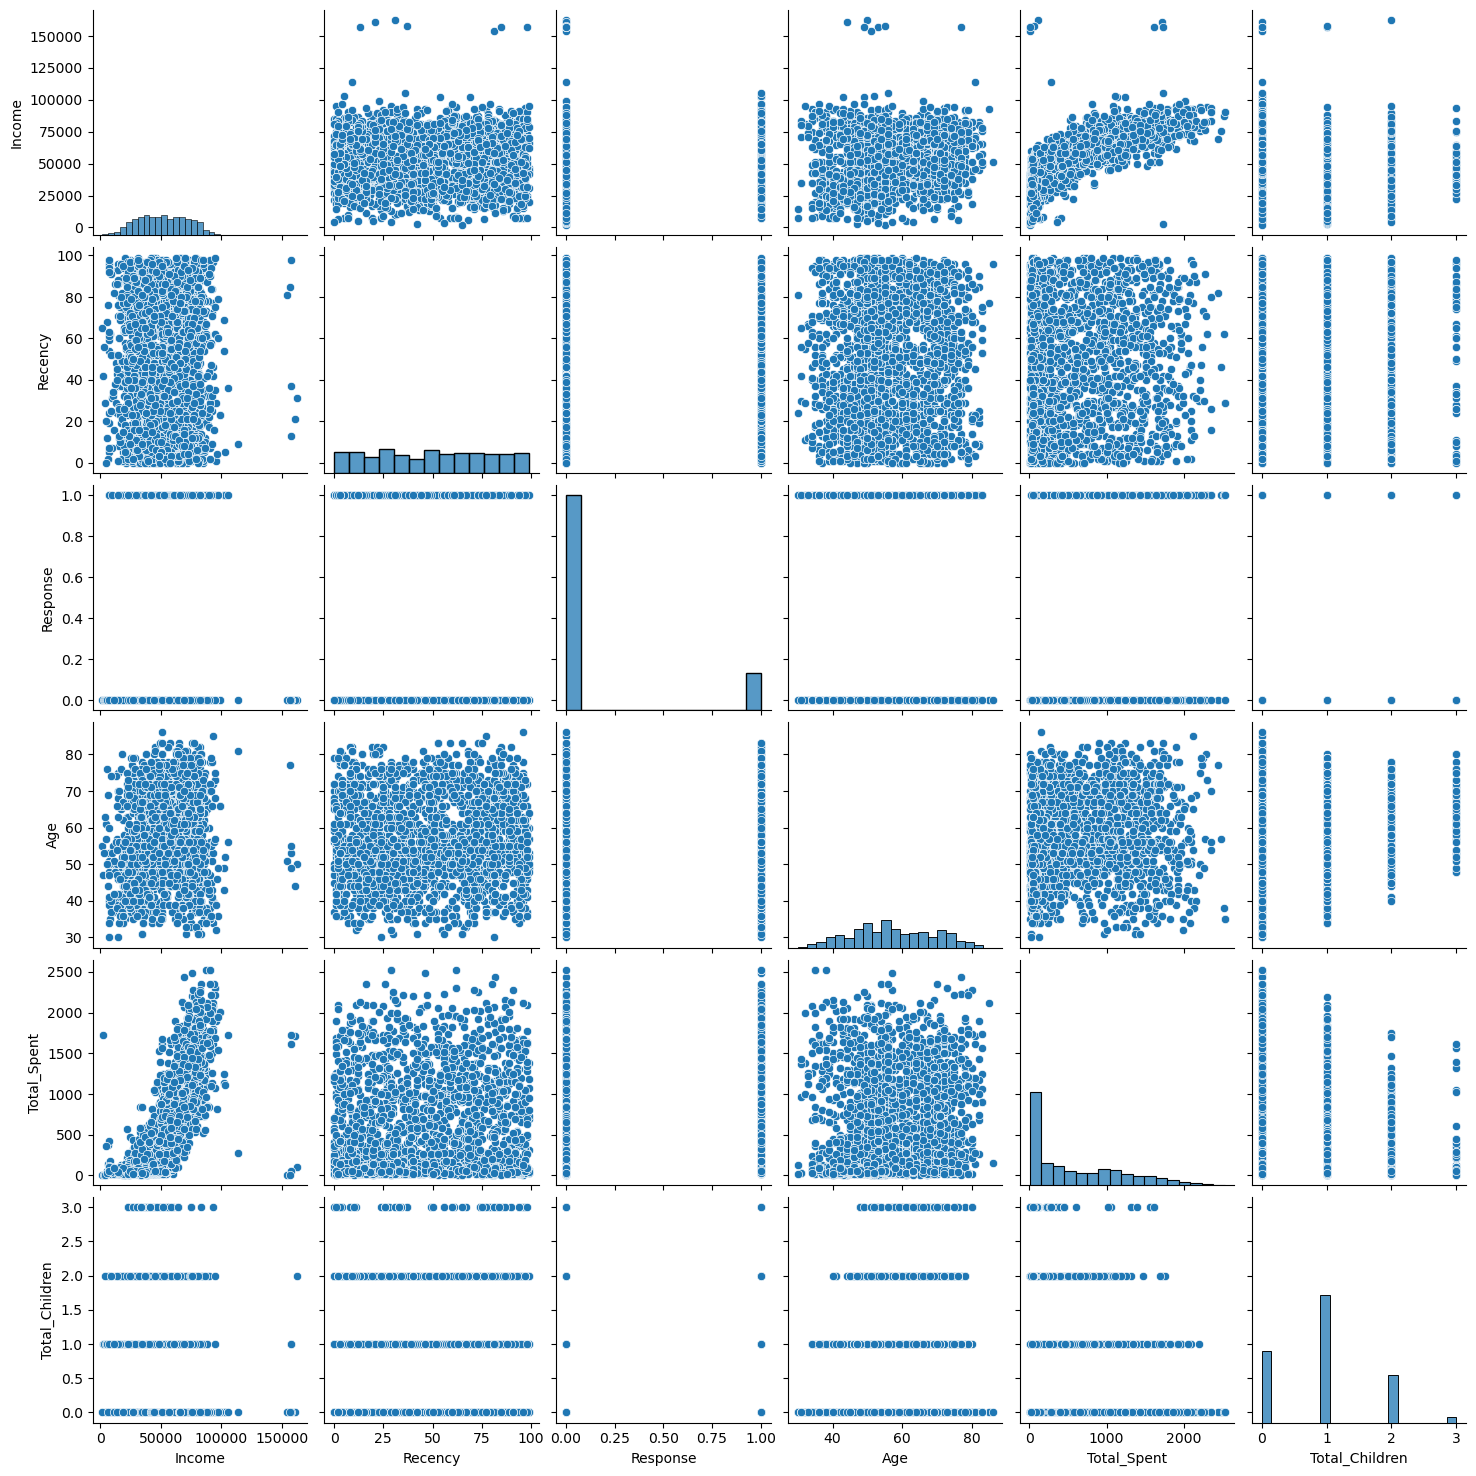

In [88]:
sns.pairplot(df_cleaned[cols])

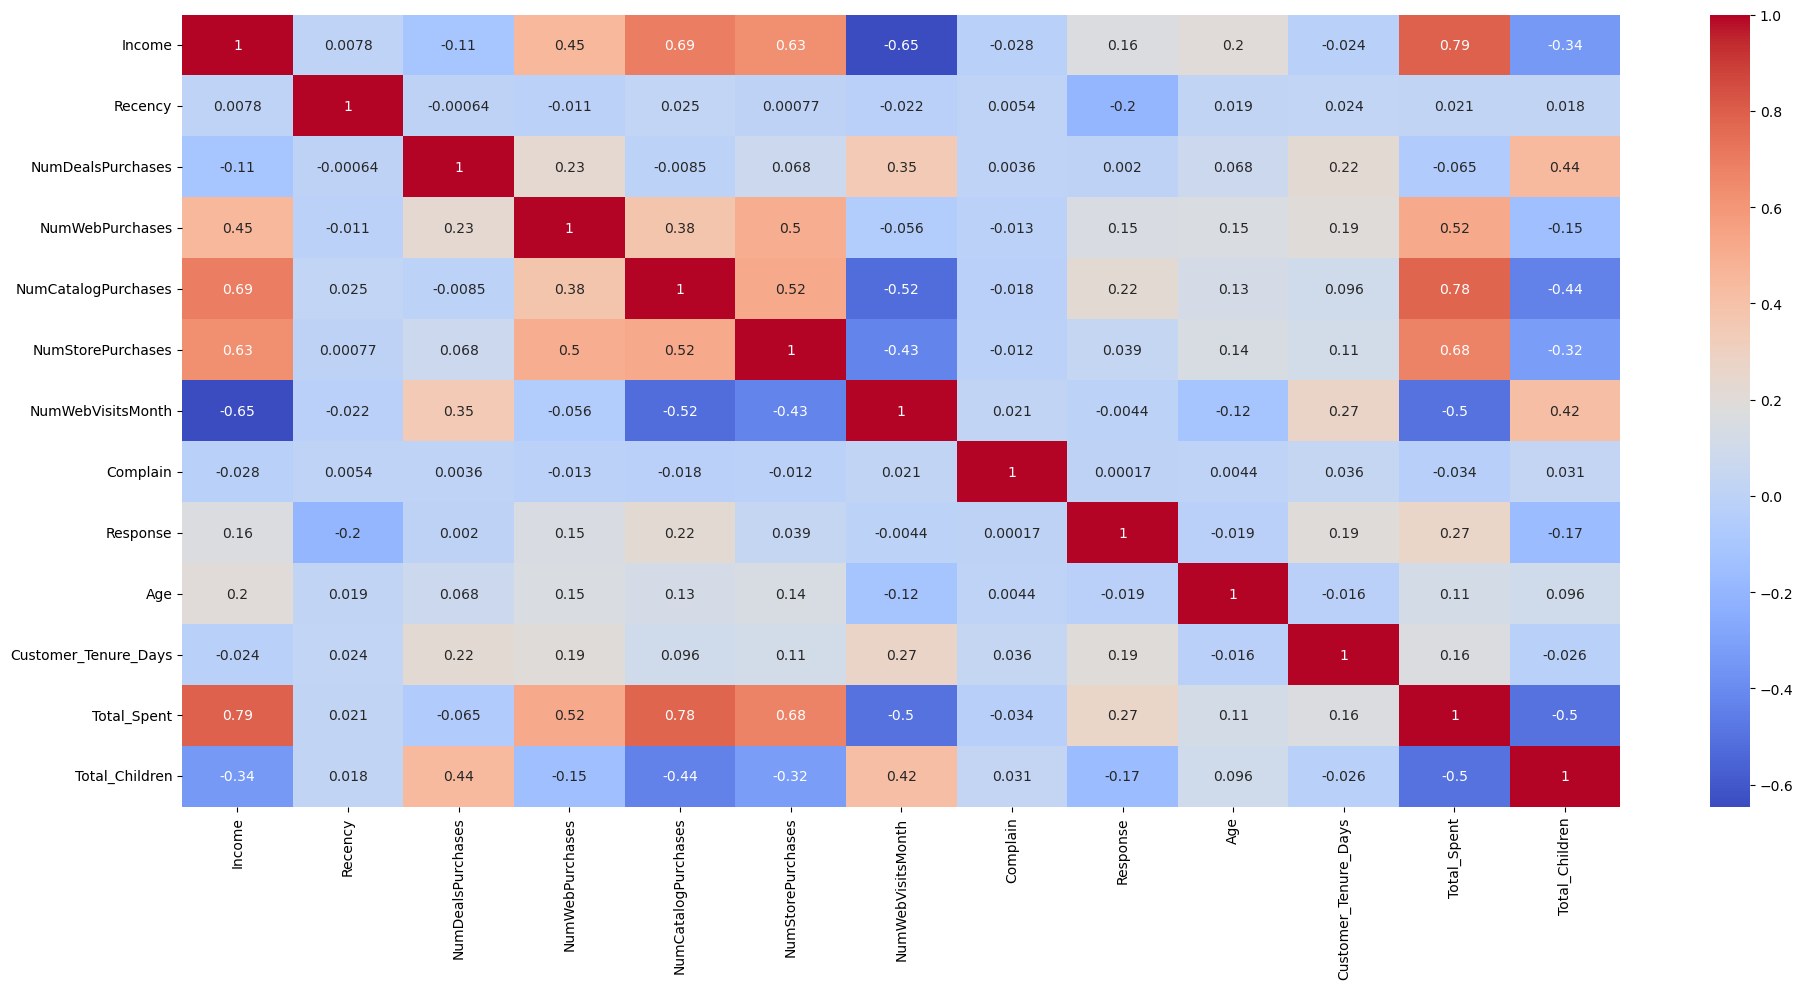

In [89]:
corr=df_cleaned.corr(numeric_only=True)
plt.figure(figsize=(20,10))

sns.heatmap(
    corr,
    annot=True,
    annot_kws={"size":10},
    cmap="coolwarm"
)
plt.tight_layout()

# Encoding

In [90]:
from sklearn.preprocessing import OneHotEncoder

cat_cols = ["Education","Living_With"]

one_hot_encoder = OneHotEncoder()

encoded_cols = one_hot_encoder.fit_transform(df_cleaned[cat_cols])


In [91]:
encoded_frame = pd.DataFrame(encoded_cols.toarray(),columns=one_hot_encoder.get_feature_names_out(cat_cols),index= df_cleaned.index)

In [92]:
df_encoded = pd.concat(
    [df_cleaned.drop(columns=cat_cols,axis=1),encoded_frame],
    axis=1
)

In [93]:
X=df_encoded

# Scaling

In [94]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

# Visualization

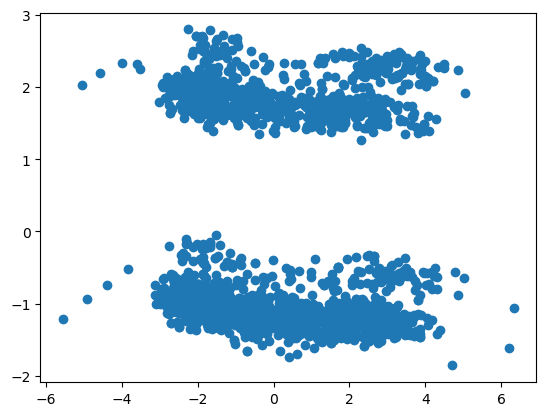

In [95]:
from sklearn.decomposition import PCA

pca = PCA(
    n_components=3
)

X_pca = pca.fit_transform(X_scaled)

plt.scatter(
    X_pca[:,0],
    X_pca[:,1],
)


In [96]:
pca.explained_variance_ratio_

array([0.23163158, 0.11385454, 0.10405815])

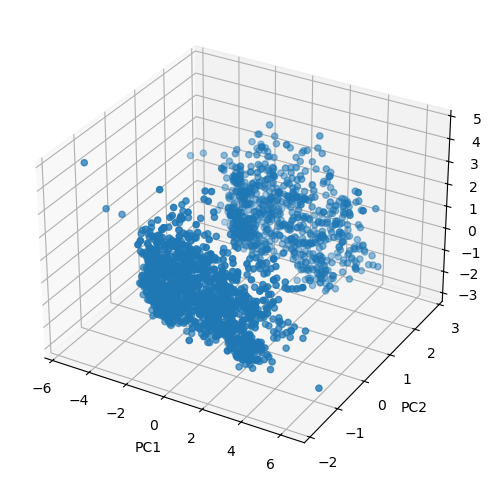

In [97]:
fig = plt.figure(figsize=(8,6))

ax = fig.add_subplot(
    111,
    projection="3d"
)

ax.scatter(
    X_pca[:,0],
    X_pca[:,1],
    X_pca[:,2]
)

ax.set_xlabel("PC1")
ax.set_ylabel("PC2")
ax.set_zlabel("PC3")
ax.set_label("3D Projection")

# Analysis of K Value

## 1. Elbow Method

In [98]:
from sklearn.cluster import KMeans
from kneed import KneeLocator

In [99]:
wcss = []

for k in range(1,11):
    kmeans = KMeans(
        n_clusters=k,
        random_state=42
    )

    kmeans.fit_predict(X_pca)

    wcss.append(kmeans.inertia_)
knee = KneeLocator(range(1,11),wcss,curve="convex",direction="decreasing")

print("Optimal K:",knee.elbow)

Optimal K: 4


c:\Users\Asus\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=9.
  warnings.warn(
c:\Users\Asus\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=9.
  warnings.warn(
c:\Users\Asus\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=9.
  warnings.warn(
c:\Users\Asus\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows wi

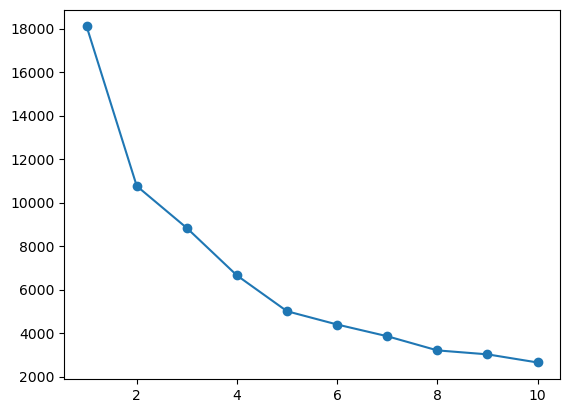

In [100]:
plt.plot(
    range(1,11),
    wcss,
    marker = 'o'
)

## 2. Silhouette Score

In [101]:
from sklearn.metrics import silhouette_score

scores = []

for k in range(2,11):
    kmeans = KMeans(
        n_clusters=k,
        random_state=42
    )

    labels =kmeans.fit_predict(X_pca)
    score = silhouette_score(X_pca,labels)
    scores.append(score)

c:\Users\Asus\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=9.
  warnings.warn(
c:\Users\Asus\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=9.
  warnings.warn(
c:\Users\Asus\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=9.
  warnings.warn(
c:\Users\Asus\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows wi

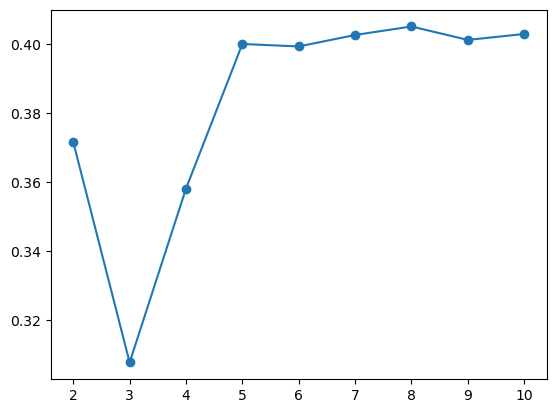

In [102]:
plt.plot(
    range(2,11),
    scores,
    marker = 'o'
)

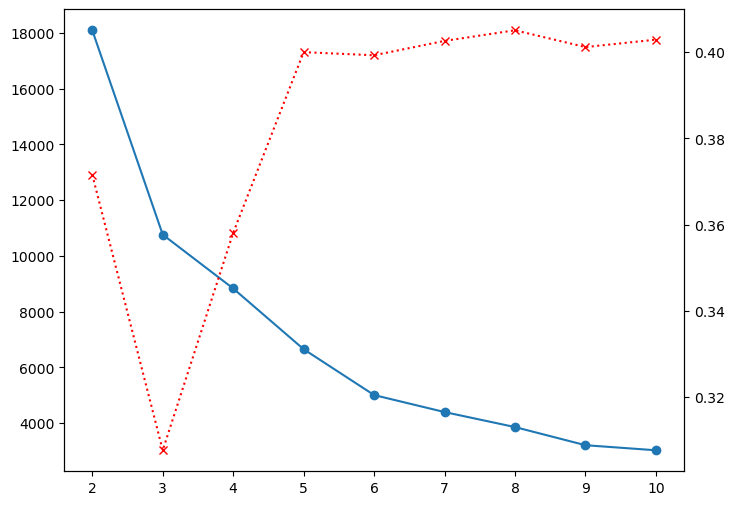

In [103]:
k_range = range(2,11)

fig,ax1 = plt.subplots(figsize = (8,6))

ax1.plot(k_range,wcss[:len(k_range)],marker = 'o')

ax2 = ax1.twinx()

ax2.plot(k_range,scores,marker = 'x',color="red",linestyle = ":")

### Pick K = 4 as Silhouette score and K values intersect near that

## Clustering

In [104]:
kmeans = KMeans(
    n_clusters=4,
    random_state=42
)

kmeans_labels = kmeans.fit_predict(X_pca)

c:\Users\Asus\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1429: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=9.
  warnings.warn(


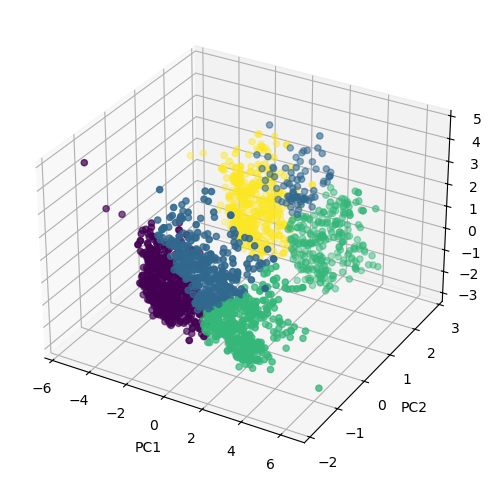

In [105]:
fig = plt.figure(figsize=(8,6))

ax = fig.add_subplot(
    111,
    projection="3d"
)

ax.scatter(
    X_pca[:,0],
    X_pca[:,1],
    X_pca[:,2],
    c=kmeans_labels
)

ax.set_xlabel("PC1")
ax.set_ylabel("PC2")
ax.set_zlabel("PC3")
ax.set_label("3D Projection")

## Hierarchical (Agglomerative)

In [106]:
from sklearn.cluster import AgglomerativeClustering

agg = AgglomerativeClustering(
    n_clusters=4,
    linkage='ward'
)

agg_labels = agg.fit_predict(X_pca)

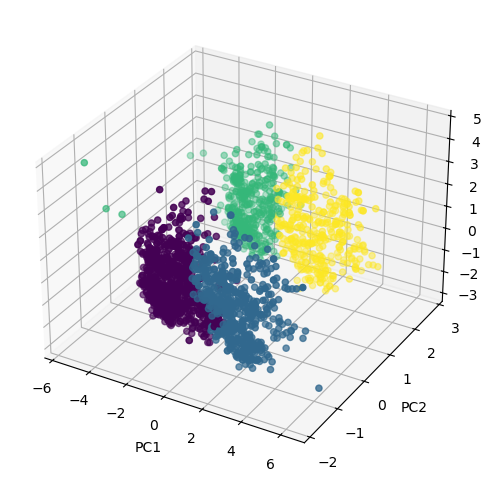

In [107]:
fig = plt.figure(figsize=(8,6))

ax = fig.add_subplot(
    111,
    projection="3d"
)

ax.scatter(
    X_pca[:,0],
    X_pca[:,1],
    X_pca[:,2],
    c=agg_labels
)

ax.set_xlabel("PC1")
ax.set_ylabel("PC2")
ax.set_zlabel("PC3")
ax.set_label("3D Projection")

## Characterization of clusters

In [108]:
df_cleaned["cluster"] = agg_labels
df_cleaned.head()

,Education,Income,Recency,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,Age,Customer_Tenure_Days,Total_Spent,Total_Children,Living_With,cluster
0,Graduate,58138.0,58,3,8,10,4,7,0,1,69,663,1617,0,Alone,3
1,Graduate,46344.0,38,2,1,1,2,5,0,0,72,113,27,2,Alone,2
2,Graduate,71613.0,26,1,8,2,10,4,0,0,61,312,776,0,Partner,1
3,Graduate,26646.0,26,2,2,0,4,6,0,0,42,139,53,1,Partner,0
4,Postgraduate,58293.0,94,5,5,3,6,5,0,0,45,161,422,1,Partner,0


<Axes: xlabel='cluster', ylabel='count'>

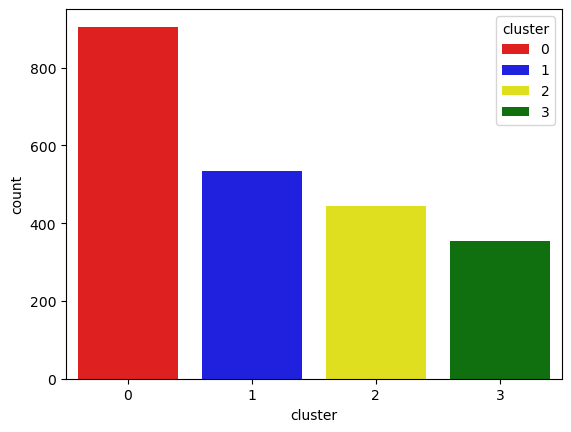

In [109]:
palette = ["red","blue","yellow","green"]

sns.countplot(x=df_cleaned["cluster"],palette=palette,hue = df_cleaned["cluster"])

<Axes: xlabel='Total_Spent', ylabel='Income'>

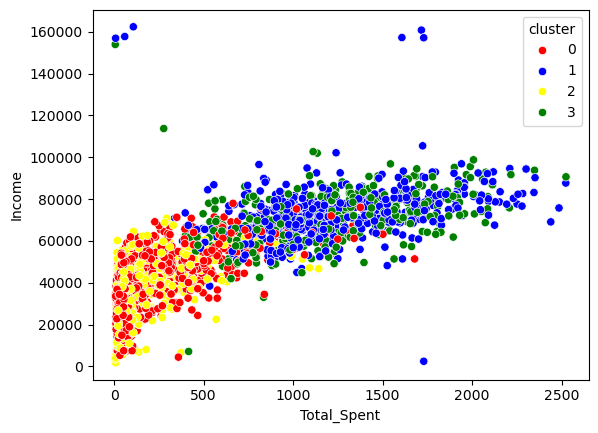

In [111]:
sns.scatterplot(
    x=df_cleaned["Total_Spent"],
    y=df_cleaned["Income"],
    hue=df_cleaned["cluster"],
    palette=palette
)

### Red(Cluster 0): Moderate spenders,Moderate Spending
### Blue(Cluster 1): High spenders,High Income
### Yellow(Cluster 2): Low spenders,Low Income
### Green(Cluster 3): High spenders,Moderate Income

<Axes: xlabel='Total_Children', ylabel='Total_Spent'>

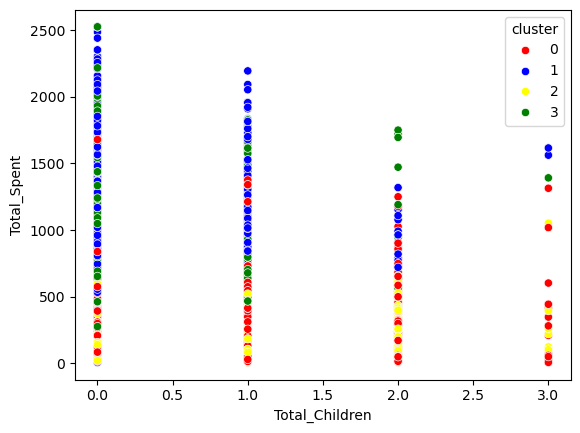

In [118]:
sns.scatterplot(
    x=df_cleaned["Total_Children"],
    y=df_cleaned["Total_Spent"],
    hue=df_cleaned["cluster"],
    palette=palette
)

In [119]:
X["cluster"] = agg_labels
cluster_summary = X.groupby("cluster").mean()
print(cluster_summary)

               Income    Recency  NumDealsPurchases  NumWebPurchases  \
cluster                                                                
0        39680.580110  48.914917           2.594475         3.153591   
1        72808.445693  49.202247           1.958801         5.687266   
2        36960.143018  48.319820           2.594595         2.713964   
3        70722.681303  50.504249           1.855524         5.790368   

         NumCatalogPurchases  NumStorePurchases  NumWebVisitsMonth  Complain  \
cluster                                                                        
0                   0.969061           4.143646           6.307182  0.011050   
1                   5.498127           8.659176           3.580524  0.005618   
2                   0.837838           3.623874           6.659910  0.011261   
3                   5.014164           8.430595           3.728045  0.005666   

         Response        Age  Customer_Tenure_Days  Total_Spent  \
cluster            

In [132]:
# Since cluster 1,3 customers spend a lot: they are premium customers

premium_customers = df_cleaned[(df_cleaned["cluster"] == 1) | (df_cleaned["cluster"] == 3)]
premium_customers.shape

(887, 16)

### After profiling, we can see:

###  Cluster 0 : Family shoppers: Moderate spenders with moderate income, likely to be family shoppers who prioritize value and quality.
###  Cluster 1 : Premium shoppers: High spenders with high income, likely to be premium shoppers who seek luxury and exclusivity.
###  Cluster 2 : Budget shoppers: Low spenders with low income, likely to be budget-conscious shoppers who prioritize affordability and discounts.
###  Cluster 3 : Value shoppers: High spenders with moderate income, likely to be value shoppers who seek a balance between quality and price. Best ROI

### We can offer discounts to Cluster 0 and Cluster 3 to encourage them to spend more, while we can offer premium products and services to Cluster 1 and Cluster 3 to cater to their preferences. For Cluster 2, we can offer budget-friendly options and promotions to attract their attention.  